# 빨간색 & 흑녹색 — "검정에 녹색을 태우면" 빨강이 더 붉어지는 이유를 수치로 확인하기

영상은 빨강 `#CC1236`(Carmine)의 짝으로 순검정 대신 **흑녹색 `#0F1A14`(Ink Green)** 을 골랐다.
"보색 관계에 톤 차이까지 극대화되어, 검정에 태운 녹색 미색이 빨강을 더 붉게 만든다"는 설명을 세 단계로 확인한다.

1. HSL로 두 색의 **색상각·채도·명도**를 구해 흑녹색이 빨강의 대략 보색 방향(녹색)에 있고, 순검정과 달리 **채도가 0이 아님**을 본다.
2. 빨강 사각형을 순검정·흑녹색·어두운 적갈색 바탕 위에 각각 놓아 **동시대비(simultaneous contrast)** 를 눈으로 비교한다.
3. "주변색의 보색 방향으로 지각이 밀린다"는 규칙을 아주 단순한 수치 모형으로 흉내 내고, CIELAB에서 빨강의 **chroma**가 어떻게 변하는지 표로 본다.

색상각 차이는 원 위의 거리이므로
$$\Delta h = \min\big(|h_1 - h_2|,\ 360^\circ - |h_1 - h_2|\big)$$
로 계산한다. $\Delta h \approx 180^\circ$ 이면 보색이다.

In [1]:
import colorsys
import os

import plotly.graph_objects as go


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

RED = "#CC1236"  # 빨간색 Carmine
INK = "#0F1A14"  # 흑녹색 Ink Green
BLACK = "#000000"  # 순검정 (비교용)
BROWN = "#1A0F12"  # 빨강 쪽으로 태운 검정 (비교용) — INK의 R/G를 맞바꾼 값


def hex_to_rgb(hex_code: str) -> tuple[float, float, float]:
    return tuple(int(hex_code[i : i + 2], 16) / 255 for i in (1, 3, 5))


def rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#" + "".join(f"{round(min(max(c, 0.0), 1.0) * 255):02X}" for c in rgb)


def hex_to_hsl(hex_code: str) -> tuple[float, float, float]:
    """'#RRGGBB' -> (hue[deg], saturation[%], lightness[%])."""
    h, l, s = colorsys.rgb_to_hls(*hex_to_rgb(hex_code))  # 표준 라이브러리는 HLS 순서
    return h * 360, s * 100, l * 100


def hue_distance(h1: float, h2: float) -> float:
    d = abs(h1 - h2) % 360
    return min(d, 360 - d)


def rel_luminance(hex_code: str) -> float:
    """WCAG 상대 휘도 (sRGB -> 선형 변환 후 가중합)."""
    lin = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in hex_to_rgb(hex_code)]
    return 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2]


def contrast_ratio(a: str, b: str) -> float:
    la, lb = sorted((rel_luminance(a), rel_luminance(b)), reverse=True)
    return (la + 0.05) / (lb + 0.05)


print(f"{'색':<10}{'HEX':<10}{'H(°)':>8}{'S(%)':>8}{'L(%)':>8}{'상대휘도':>10}")
for name, c in [("빨간색", RED), ("흑녹색", INK), ("순검정", BLACK), ("적갈검정", BROWN)]:
    h, s, l = hex_to_hsl(c)
    print(f"{name:<10}{c:<10}{h:8.1f}{s:8.1f}{l:8.1f}{rel_luminance(c):10.4f}")

h_red, _, _ = hex_to_hsl(RED)
h_ink, s_ink, _ = hex_to_hsl(INK)
print()
print(f"빨강–흑녹색 색상각 차이 Δh = {hue_distance(h_red, h_ink):.1f}°  (180°에 가까우면 보색)")
print(f"흑녹색 채도 = {s_ink:.1f}%  vs  순검정 채도 = 0.0%  → 순검정에는 색상 정보가 없다")
print(f"명암 대비율  빨강:흑녹색 = {contrast_ratio(RED, INK):.2f}:1,  빨강:순검정 = {contrast_ratio(RED, BLACK):.2f}:1")

색         HEX           H(°)    S(%)    L(%)      상대휘도
빨간색       #CC1236      348.4    83.8    43.5    0.1354
흑녹색       #0F1A14      147.3    26.8     8.0    0.0089
순검정       #000000        0.0     0.0     0.0    0.0000
적갈검정      #1A0F12      343.6    26.8     8.0    0.0060

빨강–흑녹색 색상각 차이 Δh = 158.9°  (180°에 가까우면 보색)
흑녹색 채도 = 26.8%  vs  순검정 채도 = 0.0%  → 순검정에는 색상 정보가 없다
명암 대비율  빨강:흑녹색 = 3.15:1,  빨강:순검정 = 3.71:1


## 1단계 해석

- 빨강(348°)과 흑녹색(147°)은 색상각이 약 $159^\circ$ 벌어져 있어 **거의 보색**이다.
- 명도는 43.5% vs 8.0%로 크게 벌어져 있다 — 영상이 말한 "톤 차이 극대화".
- 순검정은 채도 0, 즉 색상각이 정의되지 않는다. 흑녹색은 어둡지만 채도 26.8%의 **유채색**이다.
  이 작은 채도가 동시대비의 재료가 된다.
- 명암 대비율은 순검정 쪽이 조금 더 높다(3.71 vs 3.15). 즉 순검정은 **경계를 더 날카롭게** 만들 뿐,
  빨강의 '붉음' 자체를 강화하는 재료는 없다.

## 2단계: 동시대비를 눈으로 비교

같은 빨강 `#CC1236` 사각형을 세 바탕 위에 놓는다.
셰브뢸(Chevreul)·이텐(Itten)·앨버스(Albers)의 동시대비 규칙: **한 색은 주변색의 보색 방향으로 지각이 밀린다.**
녹색기 있는 바탕은 빨강을 더 붉게, 빨강기 있는 바탕은 빨강을 덜 붉게(탁하게) 보이게 해야 한다.

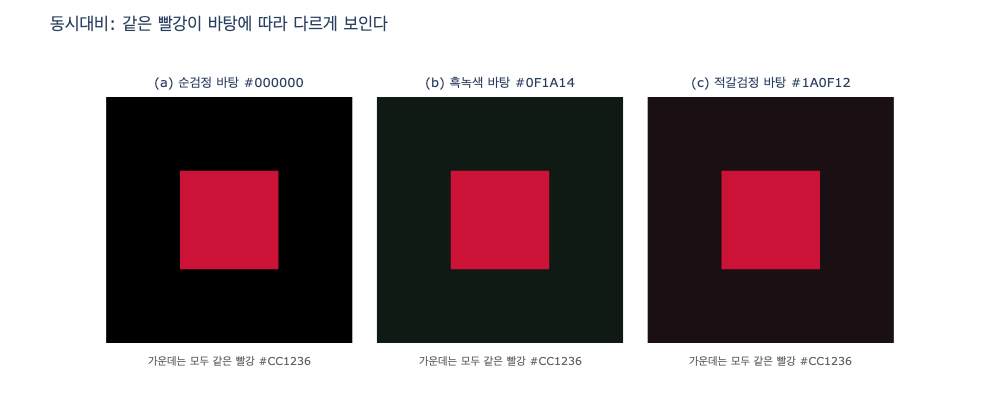

expy.png 저장 완료


In [2]:
panels = [
    ("(a) 순검정 바탕 #000000", BLACK),
    ("(b) 흑녹색 바탕 #0F1A14", INK),
    ("(c) 적갈검정 바탕 #1A0F12", BROWN),
]

fig = go.Figure()
for i, (title, bg) in enumerate(panels):
    x0 = i * 1.1
    fig.add_shape(type="rect", x0=x0, x1=x0 + 1, y0=0, y1=1, fillcolor=bg, line=dict(width=0), layer="below")
    fig.add_shape(type="rect", x0=x0 + 0.3, x1=x0 + 0.7, y0=0.3, y1=0.7, fillcolor=RED, line=dict(width=0))
    fig.add_annotation(x=x0 + 0.5, y=1.06, text=title, showarrow=False, font=dict(size=13), xanchor="center")
    fig.add_annotation(
        x=x0 + 0.5, y=-0.07, text=f"가운데는 모두 같은 빨강 {RED}", showarrow=False, font=dict(size=11, color="#666")
    )

fig.update_layout(
    title="동시대비: 같은 빨강이 바탕에 따라 다르게 보인다",
    width=1000,
    height=420,
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=20, r=20, t=60, b=40),
    xaxis=dict(range=[-0.05, 3.25], visible=False),
    yaxis=dict(range=[-0.15, 1.15], visible=False, scaleanchor="x"),
)
_show(fig)
fig.write_image(os.path.join(HERE, "expy.png"), scale=2)
print("expy.png 저장 완료")

## 3단계: '보색 방향으로 밀림'을 수치로 흉내 내기

실제 지각 모형(예: CIECAM)은 복잡하므로, 여기서는 아주 단순한 근사를 쓴다.

1. 바탕색 $B=(R,G,B)$에서 같은 밝기의 무채색 $\bar B=(m,m,m)$, $m=\tfrac{R+G+B}{3}$ 를 빼면
   바탕의 **유채 성분** $c_B = B - \bar B$ 가 남는다. 순검정은 $c_B = 0$.
2. 동시대비는 대상색을 바탕의 보색 방향으로 밀므로, 지각된 빨강을
   $$R' = R_{\text{red}} - \alpha\, c_B$$
   로 놓는다 ($\alpha$는 유도 강도, 여기서는 과장을 위해 $\alpha = 3$).
3. $R'$를 CIELAB으로 바꿔 chroma $C^*_{ab} = \sqrt{a^{*2} + b^{*2}}$ 가 원래 빨강보다 얼마나 늘었는지 본다.

sRGB → XYZ → Lab 변환은 표준식을 직접 구현한다 (D65 백색점).

In [3]:
import math

XN, YN, ZN = 0.95047, 1.00000, 1.08883  # D65


def srgb_to_lab(rgb: tuple[float, float, float]) -> tuple[float, float, float]:
    lin = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in rgb]
    r, g, b = lin
    x = 0.4124564 * r + 0.3575761 * g + 0.1804375 * b
    y = 0.2126729 * r + 0.7151522 * g + 0.0721750 * b
    z = 0.0193339 * r + 0.1191920 * g + 0.9503041 * b

    def f(t: float) -> float:
        return t ** (1 / 3) if t > (6 / 29) ** 3 else t / (3 * (6 / 29) ** 2) + 4 / 29

    fx, fy, fz = f(x / XN), f(y / YN), f(z / ZN)
    return 116 * fy - 16, 500 * (fx - fy), 200 * (fy - fz)


def chroma(lab: tuple[float, float, float]) -> float:
    return math.hypot(lab[1], lab[2])


def hue_lab(lab: tuple[float, float, float]) -> float:
    return math.degrees(math.atan2(lab[2], lab[1])) % 360


def induced_red(bg_hex: str, alpha: float = 3.0) -> tuple[float, float, float]:
    """바탕색의 유채 성분을 빨강에서 빼서(보색 방향으로 밀어서) '지각된 빨강'을 근사."""
    bg = hex_to_rgb(bg_hex)
    m = sum(bg) / 3
    c_bg = tuple(c - m for c in bg)
    red = hex_to_rgb(RED)
    return tuple(min(max(r - alpha * c, 0.0), 1.0) for r, c in zip(red, c_bg))


base_lab = srgb_to_lab(hex_to_rgb(RED))
print(f"원래 빨강 {RED}: L*={base_lab[0]:.1f}, a*={base_lab[1]:.1f}, b*={base_lab[2]:.1f}, "
      f"C*={chroma(base_lab):.1f}, h={hue_lab(base_lab):.1f}°")
print()
print(f"{'바탕':<12}{'바탕 유채성분(R,G,B×255)':<28}{'지각 빨강(근사)':<16}{'C*':>7}{'ΔC*':>8}{'Δh(°)':>8}")
for name, bg in [("순검정", BLACK), ("흑녹색", INK), ("적갈검정", BROWN)]:
    bg_rgb = hex_to_rgb(bg)
    m = sum(bg_rgb) / 3
    c_bg = ", ".join(f"{(c - m) * 255:+.0f}" for c in bg_rgb)
    r2 = induced_red(bg)
    lab2 = srgb_to_lab(r2)
    dh = (hue_lab(lab2) - hue_lab(base_lab) + 180) % 360 - 180
    print(f"{name:<12}{c_bg:<28}{rgb_to_hex(r2):<16}{chroma(lab2):7.1f}{chroma(lab2) - chroma(base_lab):+8.1f}{dh:+8.1f}")

원래 빨강 #CC1236: L*=43.6, a*=66.9, b*=32.3, C*=74.3, h=25.8°

바탕          바탕 유채성분(R,G,B×255)          지각 빨강(근사)            C*     ΔC*   Δh(°)
순검정         +0, +0, +0                  #CC1236            74.3    +0.0    +0.0
흑녹색         -5, +6, -0                  #DC0137            80.9    +6.6    +0.5
적갈검정        +6, -5, -2                  #B9203B            64.5    -9.9    -3.1


## 결과 해석

| 바탕 | 바탕의 유채 성분 | 빨강의 지각 chroma 변화 |
|---|---|---|
| 순검정 | 없음 ($c_B=0$) | **변화 없음** — 경계 명암만 세짐 |
| 흑녹색 | 녹색 쪽 | **증가** — 빨강이 더 붉고 진하게 |
| 적갈검정 | 빨강 쪽 | **감소** — 빨강이 상대적으로 탁해짐 |

순검정은 색상 정보가 없어 동시대비의 '밀어줄 방향'이 없다. 명암 대비율은 오히려 더 높으므로(3.71:1)
경계는 날카롭지만 빨강의 색 자체는 강화되지 않는다.
흑녹색은 어두운 바탕이라는 톤 대비(명도 43.5% vs 8.0%)는 거의 그대로 유지하면서, 채도 26.8%의 녹색기가
보색 방향(빨강 쪽)으로 지각을 밀어 chroma를 키운다 — 영상의 "검정에 태운 미색이 빨강을 더 붉게 만든다"가 이것이다.

반대로 어두운 부분이 순검정이 아니라 유채색이면 밝기 대비가 조금 줄어(3.15:1) 경계의 '날카로운 질감'은 살짝 무뎌진다.
대신 그림자에 색 온도가 생겨 감정이 더 원초적으로, 그리고 오래된 필름처럼 빈티지하게 읽힌다.